# Perfil residencial sintético brasileiro (Vitória-ES)

Construção de um perfil de potência residual sintético para uma residência com
sistema fotovoltaico de **5 kWp** em **Vitória-ES**, Brasil.

## Fontes de dados
- **Geração FV horária:** PVGIS (Photovoltaic Geographical Information System),
  Comissão Europeia / JRC. Base PVGIS-ERA5.  
  Disponível em: https://re.jrc.ec.europa.eu/pvg_tools/en/
- **Curva de carga residencial:** baseada em PROCEL/ELETROBRAS,
  *Pesquisa de Posse de Equipamentos e Hábitos de Uso — Classe Residencial*, 2019;
  e EPE, *Anuário Estatístico de Energia Elétrica*, 2023.
- **Irradiação solar brasileira:** PEREIRA, E. B. et al.
  *Atlas brasileiro de energia solar*. 2.ed. São José dos Campos: INPE, 2017.

## Etapas
1. Download da série horária de geração FV via API do PVGIS.
2. Definição da curva de carga residencial típica (24 h).
3. Composição do perfil de potência residual (demanda − geração FV).
4. Interpolação de horária para resolução de 1 min.
5. Exportação em formato MLBatLife (`Time`, `Power`).
6. Estimativa de SOH com modelo Random Forest pré-treinado.
7. Geração de figuras e estatísticas.

In [1]:
from pathlib import Path
import os, json, io, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = (
    Path(__file__).resolve().parent.parent.parent
    if "__file__" in dir()
    else Path.cwd().resolve().parent.parent
)
MLBAT_DIR = (BASE_DIR / "code" / "MLBatLife").resolve()
DATA_DIR  = BASE_DIR / "code" / "data" / "brasil"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR   = BASE_DIR / "pic"
OUT_DIR.mkdir(parents=True, exist_ok=True)

import sys
if str(MLBAT_DIR) not in sys.path:
    sys.path.insert(0, str(MLBAT_DIR))

import MLBatLife_Pred as blp

plt.rcParams.update({"figure.dpi": 120})

# ── Parâmetros do sistema ──
LAT       = -20.32   # Vitória-ES
LON       = -40.34
PV_KWP    = 5         # Potência de pico (kWp)
PV_LOSS   = 14        # Perdas do sistema (%)
CONS_KWH_MES = 200    # Consumo mensal médio (kWh)

# Parâmetros MLBatLife
STRATEGY  = 0   # 0: Greedy
QNOM      = 5   # kWh

# Fuso de Vitória-ES (UTC-3)
UTC_OFFSET = -3

In [2]:
# 1) Download da série horária de geração FV via PVGIS API
#    Endpoint: seriescalc  |  Base: PVGIS-ERA5 (cobertura global)
#    Referência: PVGIS © European Union, 2001-2024

PVGIS_CACHE = DATA_DIR / "pvgis_hourly.json"

if PVGIS_CACHE.exists():
    print("Carregando dados PVGIS do cache...")
    with open(PVGIS_CACHE, "r") as f:
        pvgis_data = json.load(f)
else:
    url = "https://re.jrc.ec.europa.eu/api/v5_2/seriescalc"
    params = {
        "lat":           LAT,
        "lon":           LON,
        "peakpower":     PV_KWP,
        "loss":          PV_LOSS,
        "pvcalculation": 1,
        "optimalangles": 1,
        "startyear":     2015,
        "endyear":       2019,
        "outputformat":  "json",
    }
    print(f"Requisitando PVGIS para lat={LAT}, lon={LON}, {PV_KWP} kWp ...")
    resp = requests.get(url, params=params, timeout=120)
    resp.raise_for_status()
    pvgis_data = resp.json()
    with open(PVGIS_CACHE, "w") as f:
        json.dump(pvgis_data, f)
    print("Dados salvos em cache.")

hourly_raw = pvgis_data["outputs"]["hourly"]
print(f"Registros horários recebidos: {len(hourly_raw):,}")
print(f"Primeiro: {hourly_raw[0]}")
print(f"Último:  {hourly_raw[-1]}")

Requisitando PVGIS para lat=-20.32, lon=-40.34, 5 kWp ...
Dados salvos em cache.
Registros horários recebidos: 43,824
Primeiro: {'time': '20150101:0003', 'P': 0.0, 'G(i)': 0.0, 'H_sun': 0.0, 'T2m': 24.96, 'WS10m': 4.28, 'Int': 0.0}
Último:  {'time': '20191231:2303', 'P': 0.0, 'G(i)': 0.0, 'H_sun': 0.0, 'T2m': 24.27, 'WS10m': 3.86, 'Int': 0.0}


In [3]:
# 2) Converter dados PVGIS para DataFrame
df_pv = pd.DataFrame(hourly_raw)
df_pv["ts"] = pd.to_datetime(df_pv["time"], format="%Y%m%d:%H%M")

# Ajustar fuso horário: PVGIS entrega em UTC, converter para local (UTC-3)
df_pv["ts_local"] = df_pv["ts"] + pd.Timedelta(hours=UTC_OFFSET)
df_pv["pv_W"] = df_pv["P"].clip(lower=0)  # Potência FV (W), nunca negativa

print(f"Período local: {df_pv['ts_local'].min()} → {df_pv['ts_local'].max()}")
print(f"Geração FV média: {df_pv['pv_W'].mean():.0f} W  |  máx: {df_pv['pv_W'].max():.0f} W")
print(f"Produção anual estimada: {df_pv['pv_W'].sum() / 1000:.0f} kWh ({df_pv['pv_W'].sum() / 1000 / 5:.0f} kWh/ano)")

Período local: 2014-12-31 21:03:00 → 2019-12-31 20:03:00
Geração FV média: 891 W  |  máx: 4125 W
Produção anual estimada: 39027 kWh (7805 kWh/ano)


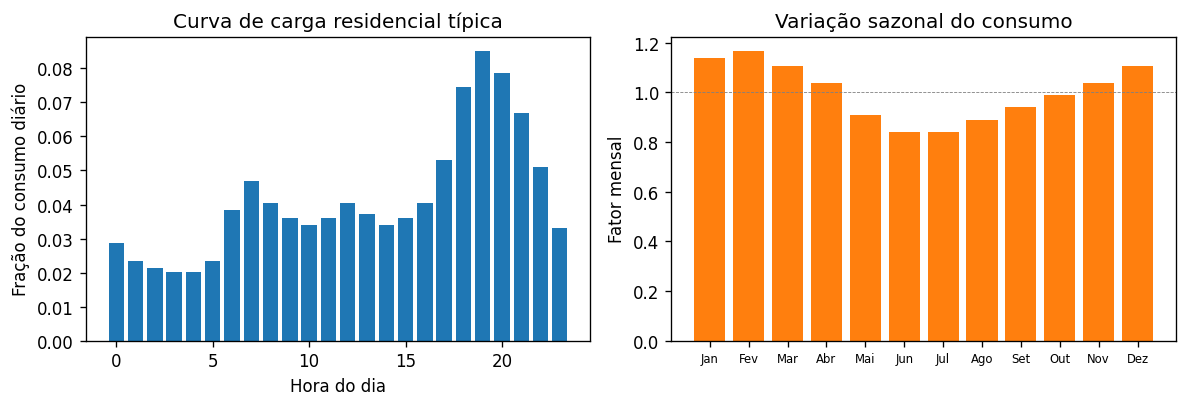

In [4]:
# 3) Curva de carga residencial típica brasileira (24 h)
#
# Baseada em:
# - PROCEL/ELETROBRAS. Pesquisa de Posse de Equipamentos e Hábitos de Uso
#   Classe Residencial. Rio de Janeiro, 2019.
# - EPE. Anuário Estatístico de Energia Elétrica. Brasília, 2023.
#
# Características:
# - Pico noturno (18h-21h): iluminação, TV, chuveiro elétrico
# - Pico matutino secundário (6h-8h): chuveiro, preparação de alimentos
# - Vale madrugada (0h-5h): standby de equipamentos

LOAD_CURVE_HOURLY = np.array([
    # 00   01    02    03    04    05    06    07    08    09    10    11
    0.027, 0.022, 0.020, 0.019, 0.019, 0.022, 0.036, 0.044, 0.038, 0.034, 0.032, 0.034,
    # 12   13    14    15    16    17    18    19    20    21    22    23
    0.038, 0.035, 0.032, 0.034, 0.038, 0.050, 0.070, 0.080, 0.074, 0.063, 0.048, 0.031,
])
LOAD_CURVE_HOURLY /= LOAD_CURVE_HOURLY.sum()  # Normalizar para soma = 1

# Fator mensal de variação sazonal (Vitória-ES, clima tropical)
# Verão (dez-mar): maior consumo por ar-condicionado
# Inverno (jun-ago): menor consumo
MONTHLY_FACTOR = np.array([
    1.15, 1.18, 1.12, 1.05,   # Jan–Abr
    0.92, 0.85, 0.85, 0.90,   # Mai–Ago
    0.95, 1.00, 1.05, 1.12,   # Set–Dez
])
MONTHLY_FACTOR /= MONTHLY_FACTOR.mean()  # Normalizar para média = 1

# Visualizar curva de carga
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.bar(range(24), LOAD_CURVE_HOURLY, color="#1f77b4")
ax1.set_xlabel("Hora do dia")
ax1.set_ylabel("Fração do consumo diário")
ax1.set_title("Curva de carga residencial típica")

meses = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
ax2.bar(range(12), MONTHLY_FACTOR, color="#ff7f0e")
ax2.set_xticks(range(12))
ax2.set_xticklabels(meses, fontsize=7)
ax2.set_ylabel("Fator mensal")
ax2.set_title("Variação sazonal do consumo")
ax2.axhline(1, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig(OUT_DIR / "brasil_curva_carga.png", dpi=300)
plt.show()

In [5]:
# 4) Compor perfil de potência residual horário (demanda − geração FV)
#
# Consumo horário (W) = (consumo_mensal × fator_mensal / dias_no_mês) × fração_horária × 1000
# Potência residual (W) = demanda_W − pv_W

df_pv["month"] = df_pv["ts_local"].dt.month
df_pv["hour"]  = df_pv["ts_local"].dt.hour
df_pv["day_of_month"] = df_pv["ts_local"].dt.day
df_pv["days_in_month"] = df_pv["ts_local"].dt.days_in_month

# Consumo diário do mês (kWh)
df_pv["daily_cons_kWh"] = (
    CONS_KWH_MES * MONTHLY_FACTOR[df_pv["month"].values - 1]
    / df_pv["days_in_month"].values
)

# Demanda horária (W) = consumo_diário(kWh) × fração_horária × 1000
df_pv["demand_W"] = (
    df_pv["daily_cons_kWh"].values
    * LOAD_CURVE_HOURLY[df_pv["hour"].values]
    * 1000
)

# Potência residual (demanda − PV)
df_pv["residual_W"] = df_pv["demand_W"] - df_pv["pv_W"]

print(f"Demanda média: {df_pv['demand_W'].mean():.0f} W")
print(f"Geração FV média: {df_pv['pv_W'].mean():.0f} W")
print(f"Residual médio: {df_pv['residual_W'].mean():.0f} W")
print(f"Residual min: {df_pv['residual_W'].min():.0f} W  |  max: {df_pv['residual_W'].max():.0f} W")

Demanda média: 274 W
Geração FV média: 891 W
Residual médio: -617 W
Residual min: -3866 W  |  max: 709 W


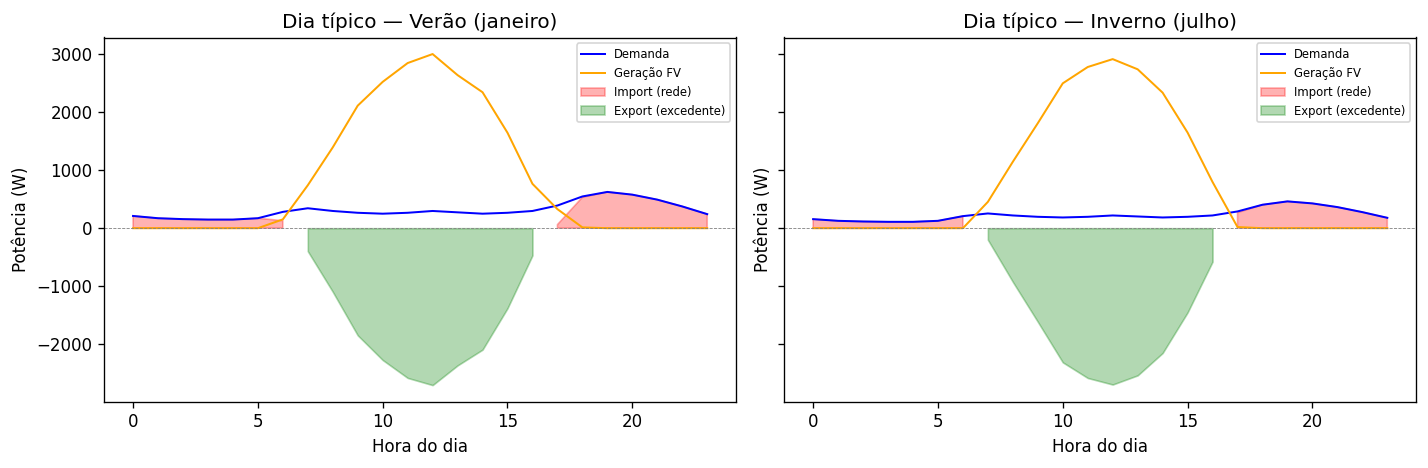

In [6]:
# 5) Visualizar perfil horário — dia típico de verão e inverno
summer = df_pv[(df_pv["month"] == 1) & (df_pv["ts_local"].dt.year == 2016)]
winter = df_pv[(df_pv["month"] == 7) & (df_pv["ts_local"].dt.year == 2016)]

def plot_typical_day(subset, title, ax):
    hourly_avg = subset.groupby("hour").agg(
        demand=("demand_W", "mean"),
        pv=("pv_W", "mean"),
        residual=("residual_W", "mean"),
    )
    ax.plot(hourly_avg.index, hourly_avg["demand"], "b-", label="Demanda", linewidth=1.2)
    ax.plot(hourly_avg.index, hourly_avg["pv"],     "orange", label="Geração FV", linewidth=1.2)
    ax.fill_between(hourly_avg.index, hourly_avg["residual"], 0,
                    where=hourly_avg["residual"] >= 0, alpha=0.3, color="red", label="Import (rede)")
    ax.fill_between(hourly_avg.index, hourly_avg["residual"], 0,
                    where=hourly_avg["residual"] < 0, alpha=0.3, color="green", label="Export (excedente)")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Hora do dia")
    ax.set_ylabel("Potência (W)")
    ax.set_title(title)
    ax.legend(fontsize=7)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_typical_day(summer, "Dia típico — Verão (janeiro)", ax1)
plot_typical_day(winter, "Dia típico — Inverno (julho)", ax2)
plt.tight_layout()
plt.savefig(OUT_DIR / "brasil_perfil_tipico.png", dpi=300)
plt.show()

In [7]:
# 6) Interpolação horária → 1 min e criação do CSV MLBatLife
#
# A interpolação linear entre valores horários preserva a energia total
# e suaviza a transição entre intervalos.

# Alinhar ao início do primeiro dia completo (hora 0 em horário local)
df_sorted = df_pv.sort_values("ts_local").reset_index(drop=True)

# Encontrar primeira hora 0 em horário local
# (PVGIS usa offset de alguns minutos, então checamos apenas a hora)
first_h0_mask = df_sorted["ts_local"].dt.hour == 0
first_idx = df_sorted.loc[first_h0_mask].index[0]
df_sorted = df_sorted.iloc[first_idx:].reset_index(drop=True)

# Truncar em dias completos (24 horas/dia)
n_days = len(df_sorted) // 24
df_sorted = df_sorted.iloc[:n_days * 24].copy()

print(f"Período alinhado: {df_sorted['ts_local'].iloc[0]} → {df_sorted['ts_local'].iloc[-1]}")
print(f"Dias completos: {n_days}")

# Interpolar para 1 min: cada hora gera 60 pontos
residual_hourly = df_sorted["residual_W"].values

# Criar série com resolução de 1 minuto via interpolação linear
ts_hourly = np.arange(len(residual_hourly))  # índice horário (0, 1, 2, ...)
ts_minute = np.arange(len(residual_hourly) * 60) / 60.0  # índice em horas com passo de 1/60

residual_1min = np.interp(ts_minute, ts_hourly, residual_hourly)

# Truncar em dias completos de 1440 min
n_days_1min = len(residual_1min) // 1440
residual_1min = residual_1min[:n_days_1min * 1440]

# Criar DataFrame MLBatLife
df_brasil = pd.DataFrame({
    "Time":  np.arange(len(residual_1min), dtype=float),
    "Power": residual_1min,
})

out_csv = DATA_DIR / "profile_brasil_vitoria.csv"
df_brasil.to_csv(out_csv, index=False)
print(f"\nPerfil salvo: {out_csv.name}")
print(f"Linhas: {len(df_brasil):,}  |  Dias: {n_days_1min}")

Período alinhado: 2015-01-01 00:03:00 → 2019-12-30 23:03:00
Dias completos: 1825

Perfil salvo: profile_brasil_vitoria.csv
Linhas: 2,628,000  |  Dias: 1825


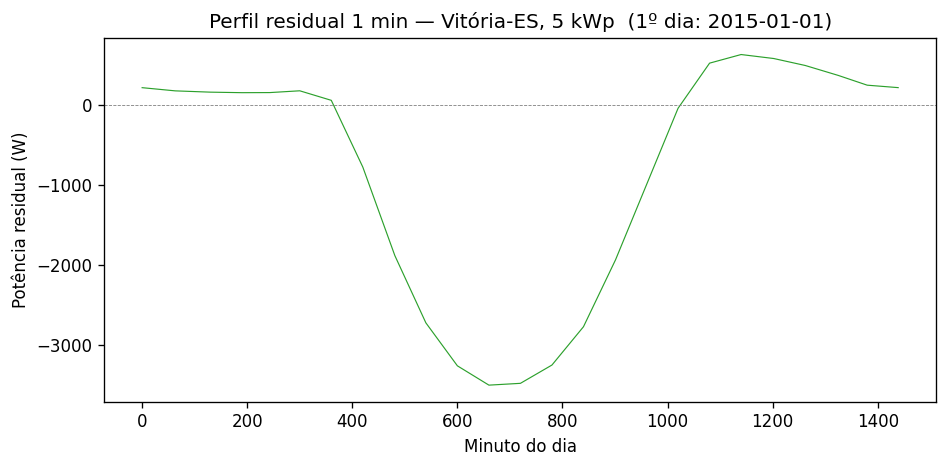

In [8]:
# 7) Perfil de potência residual — primeiro dia (1 min)
minutes = np.arange(1440)
day1 = df_brasil["Power"].values[:1440]

plt.figure(figsize=(8, 4))
plt.plot(minutes, day1, color="#2ca02c", linewidth=0.7)
plt.axhline(0, color="gray", linewidth=0.5, linestyle="--")
plt.xlabel("Minuto do dia")
plt.ylabel("Potência residual (W)")
start_date = df_sorted["ts_local"].iloc[0].date()
plt.title(f"Perfil residual 1 min — Vitória-ES, {PV_KWP} kWp  (1º dia: {start_date})")
plt.tight_layout()
plt.savefig(OUT_DIR / "brasil_perfil_1min_dia1.png", dpi=300)
plt.show()

In [9]:
# 8) Estimativa de SOH
os.chdir(MLBAT_DIR)

m_time   = df_brasil["Time"].values
inp_prof = df_brasil["Power"].values

features, day = blp.extract_features(m_time, inp_prof)
soh_hat       = blp.estimate_soh(features, day, STRATEGY, QNOM)

print(f"Dias estimados: {len(day)}")
print(f"SOH final: {soh_hat[-1]:.6f}")
print(f"T1 médio: {features[:, 0].mean():.1f} W  |  T4 médio: {features[:, 1].mean():.1f} W")

Dias estimados: 1825
SOH final: 0.805467
T1 médio: -616.6 W  |  T4 médio: 931.8 W


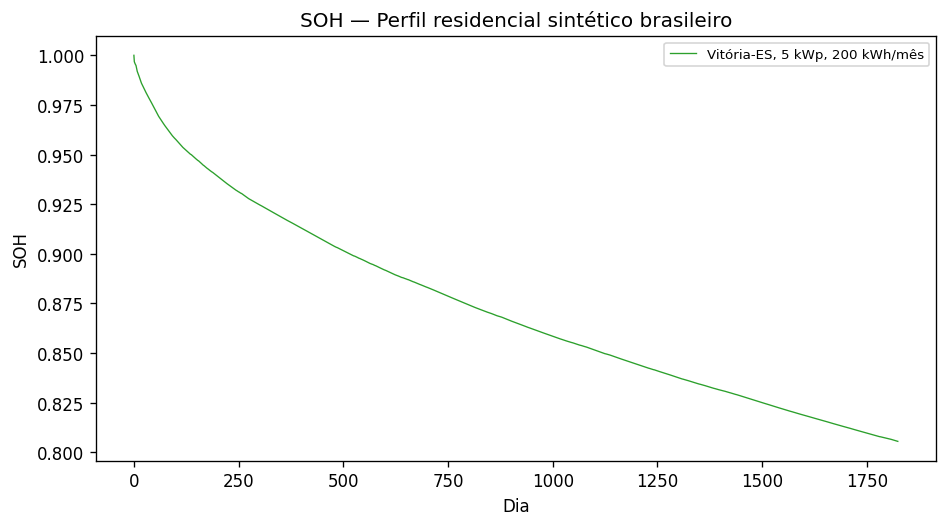

In [10]:
# 9) SOH ao longo do tempo
plt.figure(figsize=(8, 4.5))
plt.plot(day, soh_hat, color="#2ca02c", linewidth=0.8,
         label=f"Vitória-ES, {PV_KWP} kWp, {CONS_KWH_MES} kWh/mês")
plt.xlabel("Dia")
plt.ylabel("SOH")
plt.title("SOH — Perfil residencial sintético brasileiro")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "brasil_soh.png", dpi=300)
plt.show()

In [11]:
# 10) Estatísticas resumidas
soh_daily_br = pd.DataFrame({"Dia": day, "SOH_est": soh_hat})
soh_daily_br.to_csv(OUT_DIR / "brasil_soh_daily.csv", index=False)

summary_br = pd.DataFrame({
    "Parâmetro": [
        "Local", "Latitude", "Longitude",
        "Potência FV (kWp)", "Consumo mensal (kWh)",
        "Estratégia", "Qnom (kWh)",
        "Dias simulados",
        "SOH final", "SOH mín",
        "T1 médio (W)", "T4 médio (W)",
    ],
    "Valor": [
        "Vitória-ES", LAT, LON,
        PV_KWP, CONS_KWH_MES,
        "Greedy", QNOM,
        len(day),
        round(float(soh_hat[-1]), 6),
        round(float(soh_hat.min()), 6),
        round(float(features[:, 0].mean()), 1),
        round(float(features[:, 1].mean()), 1),
    ],
})
summary_br.to_csv(OUT_DIR / "brasil_soh_summary.csv", index=False)
summary_br

,Parâmetro,Valor
0,Local,Vitória-ES
1,Latitude,-20.32
2,Longitude,-40.34
3,Potência FV (kWp),5
4,Consumo mensal (kWh),200
5,Estratégia,Greedy
6,Qnom (kWh),5
7,Dias simulados,1825
8,SOH final,0.805467
9,SOH mín,0.805467
